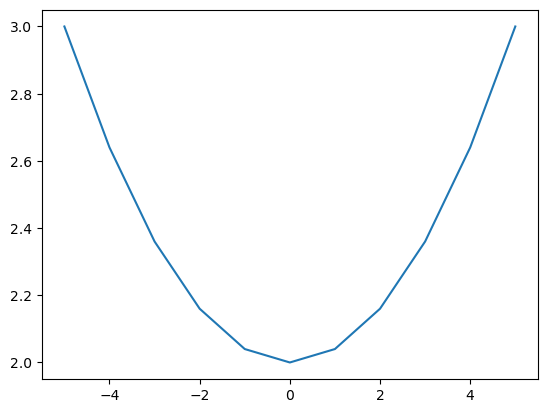

In [20]:

import numpy as np
import h5py
import matplotlib.pyplot as plt
import tifffile as tiff

# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)

# ------------ Data generation parameters  --------------
MONTE_CARLO_SAMPLES = 10
PSFW = 2
WIDTH = 50
HEIGTH = 50
BCKG = 100
UPSCALE = 4
DEG = np.pi/180.
THETA_STEP = 45*DEG
snrs = np.logspace(0, 3, 11)

# ------------ Helper functions  --------------


def gauss_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    Computes a 2D Gaussian function.

    Parameters:
        xy (tuple of ndarray): A tuple containing two 2D arrays (x, y) representing the grid coordinates.
        amplitude (float): The amplitude (peak value) of the Gaussian function.
        xo (float): The x-coordinate of the center of the Gaussian.
        yo (float): The y-coordinate of the center of the Gaussian.
        sigma_x (float): The standard deviation of the Gaussian in the x-direction.
        sigma_y (float): The standard deviation of the Gaussian in the y-direction.
        theta (float): The rotation angle of the Gaussian in radians.
        offset (float): The constant offset added to the Gaussian function.

    Returns:
        ndarray: A 1D array representing the raveled 2D Gaussian function values.
        It need to be reshaped to form a 2D array.
    """
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp(- (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo)
                                     + c*((y-yo)**2)))
    return g.ravel()


def generate_image(xyi, noise_mean, noise_std, psf_width, h, w):
    """
    Generates a 2D image with Gaussian point sources and added noise.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_width (float): The width of the point spread function (PSF) for the Gaussian sources.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img = RNG.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)
    ys = np.arange(h)
    xs = np.arange(w)
    xy = np.meshgrid(xs, ys)
    for x, y, intensity in xyi:
        int_correction = (psf_width/PSFW)**2
        img += gauss_2d(xy, intensity/int_correction, x, y, psf_width,
                        psf_width, 0, 0).reshape((h, w))
    # img = (img - np.min(img))
    # img = img/np.sum(img)
    return img



# Generate coordinates of the star-shaped pattern.
intensity = 5000
xyis = np.array([(15, 35, intensity), (35, 25, intensity), (20, 10, intensity)])

PSFW = 2
zs = np.linspace(-5,5,11)
psf_w = PSFW + (zs/5)**2

plt.plot(zs, psf_w)
plt.show()

In [21]:
stack_for_z_calib = np.array([generate_image(xyis, 150, 50, _sigma, HEIGTH, WIDTH) for _sigma in psf_w]).clip(0, 2**16-1).astype(np.uint16)


with tiff.TiffWriter('z-stack.tiff', imagej=True) as writer:
    writer.write(stack_for_z_calib)

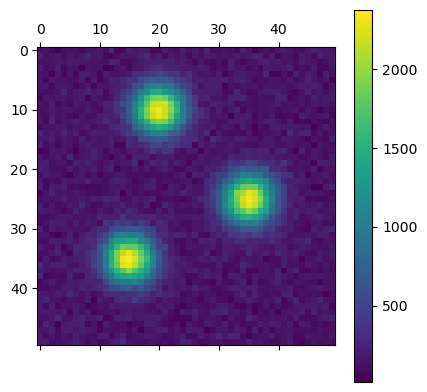

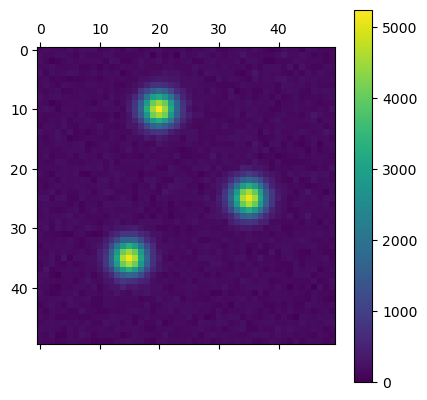

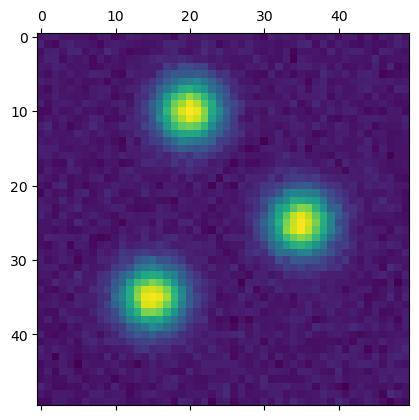

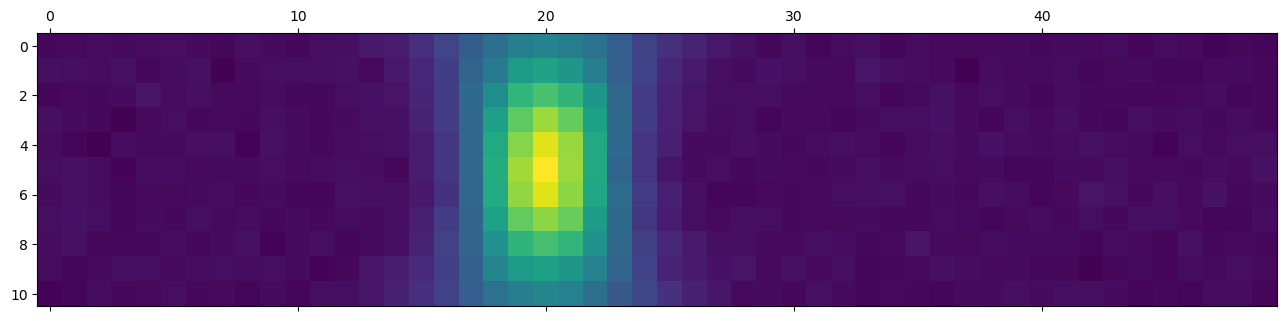

In [24]:
plt.matshow(stack_for_z_calib[0])
plt.colorbar()
plt.matshow(stack_for_z_calib[5])
plt.colorbar()
plt.matshow(stack_for_z_calib[10])
plt.matshow(stack_for_z_calib[:,10,:])